# Librerias

In [ ]:
def separador():
    print("\n" + "=" * 170 + "\n")
def header(Titulo):
  por=((170-len(Titulo))//10)
  a=int(1.2*por)
  print("."*a+"·"*a+"~"*a+"≈"*a+"≋"
  *int(por*.2),Titulo,"≋"*int(por*.2)
  +"≈"*a+"~"*a+"·"*a+"."*a,"\n\n")

In [ ]:
#para el df y el procesamiento del texto
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem import WordNetLemmatizer
#modelos
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

nltk.download('all')
try:
  stopwords.words('english')
except:
  nltk.download('stopwords')


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

# EDA (Exploratory Data Analysis)

                                              review  sentimento
0  One of the other reviewers has mentioned that ...           1
1  A wonderful little production. <br /><br />The...           1
2  I thought this was a wonderful way to spend ti...           1
3  Basically there's a family where a little boy ...           0
4  Petter Mattei's "Love in the Time of Money" is...           1
5  Probably my all-time favorite movie, a story o...           1
6  I sure would like to see a resurrection of a u...           1
7  This show was an amazing, fresh & innovative i...           0
8  Encouraged by the positive comments about this...           0
9  If you like original gut wrenching laughter yo...           1


valores nulos:
review        0
sentimento    0
dtype: int64


filas del df:
50000
columnas del df:
2


Axes(0.125,0.11;0.775x0.77)


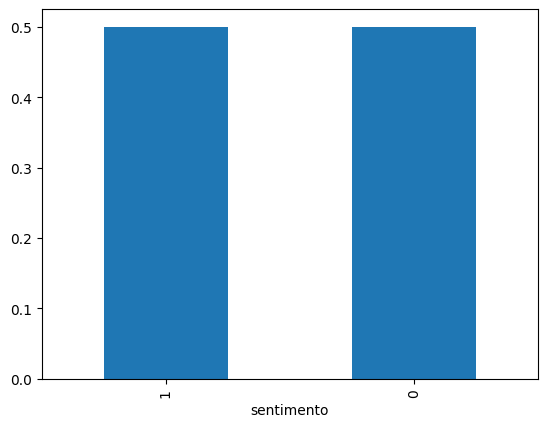

In [ ]:
#Se importa el csv y se muestran las 10 primeras filas
datos=pd.read_csv('/content/drive/MyDrive/MAESTRIA/PLN/IMDB Reviews(in).csv')
print(f'Primeras 10 filas:\n{datos.head(10)}');separador()
#valores faltantes
print(f'valores nulos:\n{datos.isna().sum()}');separador()
#shape del df
print(f'filas del df:\n{datos.shape[0]}\ncolumnas del df:\n{datos.shape[1]}');separador()
#balance del target
print(datos['sentimento'].value_counts(normalize=True).plot.bar())

# Tratamiento del texto

In [ ]:
#Se eliminan etiquetas HTML, caracteres que no sean letras, los stopwords y se minimiza.
lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))
def limpiar_texto(texto):
  texto_limpio=re.sub(re.compile('<.*?>'), '', texto)
  texto_limpio= re.sub('[^a-zA-Z]', ' ', texto_limpio)
  texto_limpio=texto_limpio.lower()
  #texto_limpio=[lemmatizer.lemmatize(palabra) for palabra in texto]
  #ahora los stopwords
  palabras=texto_limpio.split()
  palabras_filtradas=[palabra for palabra in palabras if palabra not in stop_words]
  palabras_filtradas=[lemmatizer.lemmatize(palabra) for palabra in palabras_filtradas]
  return ' '.join(palabras_filtradas)
datos['review_limpia']=datos['review'].apply(limpiar_texto)#se aplica la función de limpieza a la columna "review"


In [ ]:
print(datos['review_limpia'].head(10));separador()

0    one reviewer mentioned watching oz episode hoo...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically family little boy jake think zombie ...
4    petter mattei love time money visually stunnin...
5    probably time favorite movie story selflessnes...
6    sure would like see resurrection dated seahunt...
7    show amazing fresh innovative idea first aired...
8    encouraged positive comment film looking forwa...
9    like original gut wrenching laughter like movi...
Name: review_limpia, dtype: object




#Vectorización BOW y TF-IDF y train_Test_split



In [ ]:
X=datos['review_limpia']
y=datos['sentimento'] #es sentimento, tiene un error esa palabra
#80 para train y 20 para test
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba=train_test_split(X, y, test_size=0.2, random_state=9)
#BOW
vectorizador_bow=CountVectorizer()
X_entrenamiento_bow=vectorizador_bow.fit_transform(X_entrenamiento)
X_prueba_bow=vectorizador_bow.transform(X_prueba)

#TF-IDF
vectorizador_tfidf=TfidfVectorizer()
X_entrenamiento_tfidf=vectorizador_tfidf.fit_transform(X_entrenamiento)
X_prueba_tfidf=vectorizador_tfidf.transform(X_prueba)

#Modelados y Matrices de confusión

##Modelos

In [ ]:
#diccionario de modelos para usarlos en la función mas adelante
modelos={
'Naive Bayes': MultinomialNB(),
'SVM': SGDClassifier(loss='hinge', random_state=9),
'Random Forest': RandomForestClassifier(n_estimators=100, random_state=9),
'KNN': KNeighborsClassifier(n_neighbors=5),
'Logistic Regression': LogisticRegression(max_iter=1000, random_state=9)}

###RandomizedSearchCV + modelado + matrices

Reporte con BOW:



Modelo:Naive Bayes
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.84      0.88      0.86      5023
Clase 1 (Positiva)       0.87      0.83      0.85      4977

          accuracy                           0.86     10000
         macro avg       0.86      0.86      0.86     10000
      weighted avg       0.86      0.86      0.86     10000

AUC: 0.9244



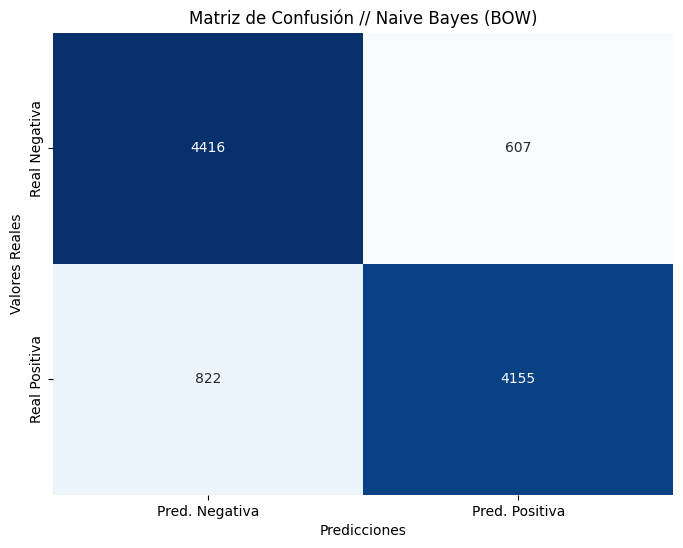



Modelo:SVM
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.86      0.89      0.88      5023
Clase 1 (Positiva)       0.89      0.86      0.87      4977

          accuracy                           0.87     10000
         macro avg       0.88      0.87      0.87     10000
      weighted avg       0.88      0.87      0.87     10000

AUC: 0.9423



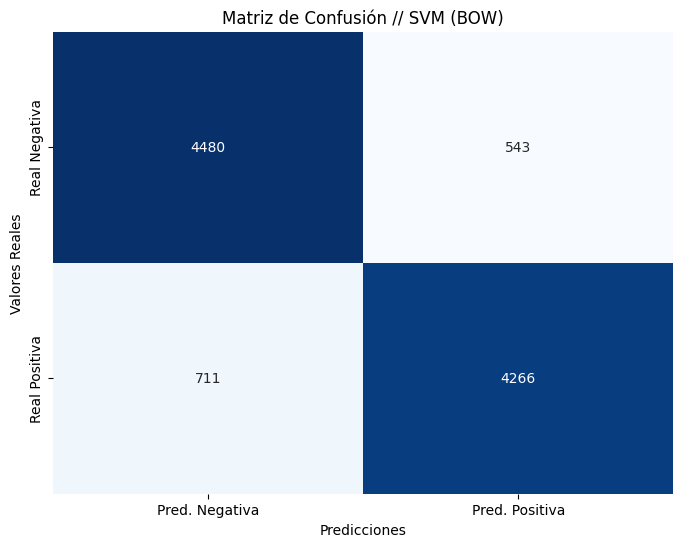



Modelo:Random Forest
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.86      0.86      0.86      5023
Clase 1 (Positiva)       0.86      0.86      0.86      4977

          accuracy                           0.86     10000
         macro avg       0.86      0.86      0.86     10000
      weighted avg       0.86      0.86      0.86     10000

AUC: 0.9358



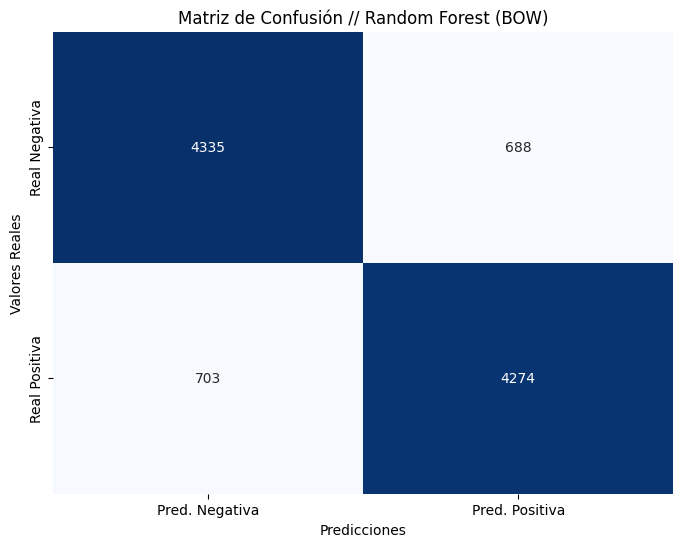



Modelo:KNN
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.65      0.61      0.63      5023
Clase 1 (Positiva)       0.63      0.66      0.65      4977

          accuracy                           0.64     10000
         macro avg       0.64      0.64      0.64     10000
      weighted avg       0.64      0.64      0.64     10000

AUC: 0.6825



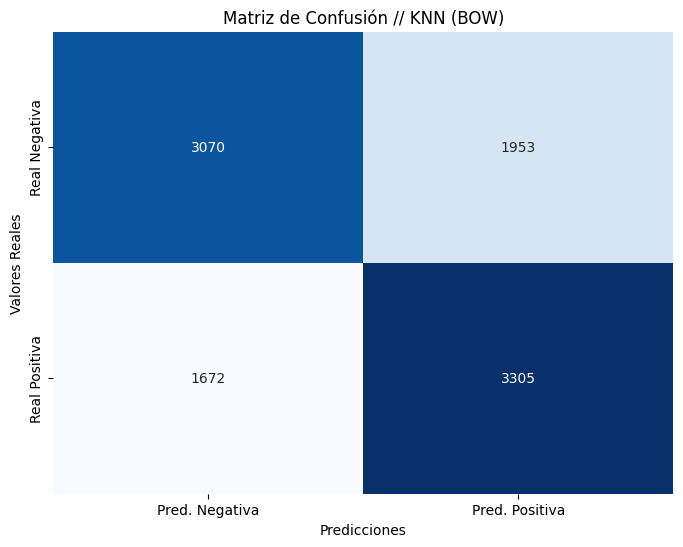



Modelo:Logistic Regression
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.88      0.88      0.88      5023
Clase 1 (Positiva)       0.88      0.88      0.88      4977

          accuracy                           0.88     10000
         macro avg       0.88      0.88      0.88     10000
      weighted avg       0.88      0.88      0.88     10000

AUC: 0.9466



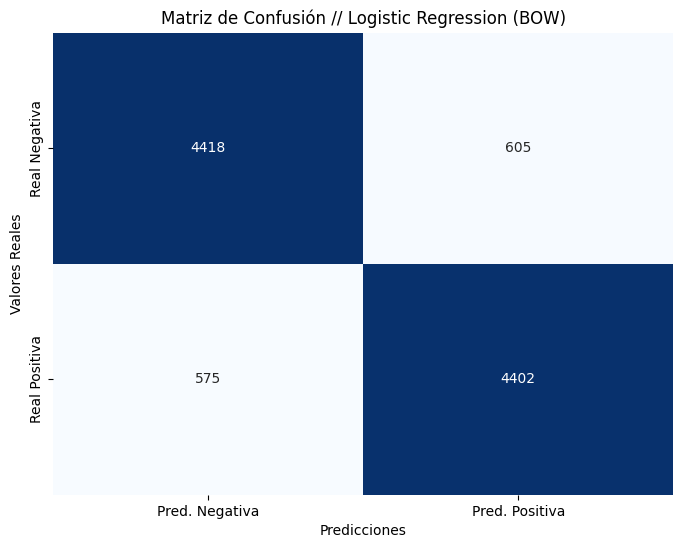



Reporte con TF-IDF:



Modelo:Naive Bayes
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.86      0.88      0.87      5023
Clase 1 (Positiva)       0.87      0.85      0.86      4977

          accuracy                           0.87     10000
         macro avg       0.87      0.87      0.87     10000
      weighted avg       0.87      0.87      0.87     10000

AUC: 0.9365



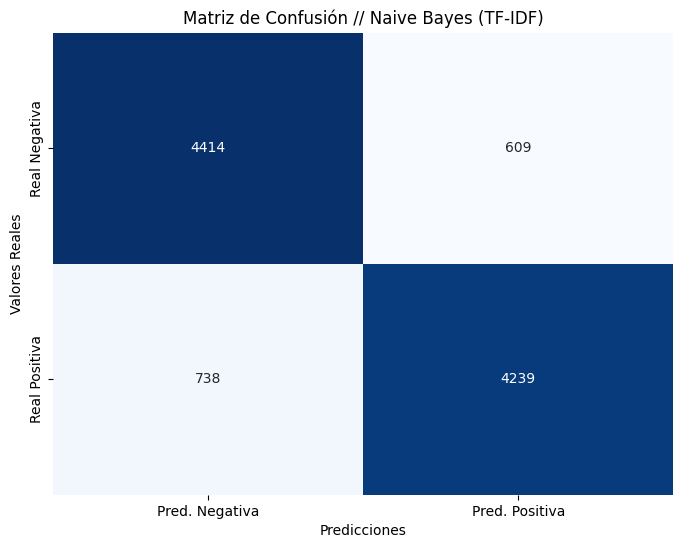



Modelo:SVM
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.91      0.88      0.89      5023
Clase 1 (Positiva)       0.88      0.91      0.89      4977

          accuracy                           0.89     10000
         macro avg       0.89      0.89      0.89     10000
      weighted avg       0.89      0.89      0.89     10000

AUC: 0.9590



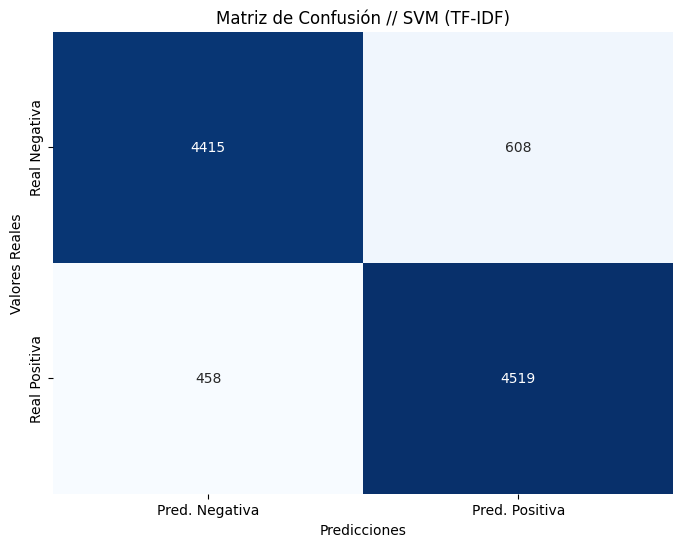



Modelo:Random Forest
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.86      0.86      0.86      5023
Clase 1 (Positiva)       0.86      0.85      0.86      4977

          accuracy                           0.86     10000
         macro avg       0.86      0.86      0.86     10000
      weighted avg       0.86      0.86      0.86     10000

AUC: 0.9315



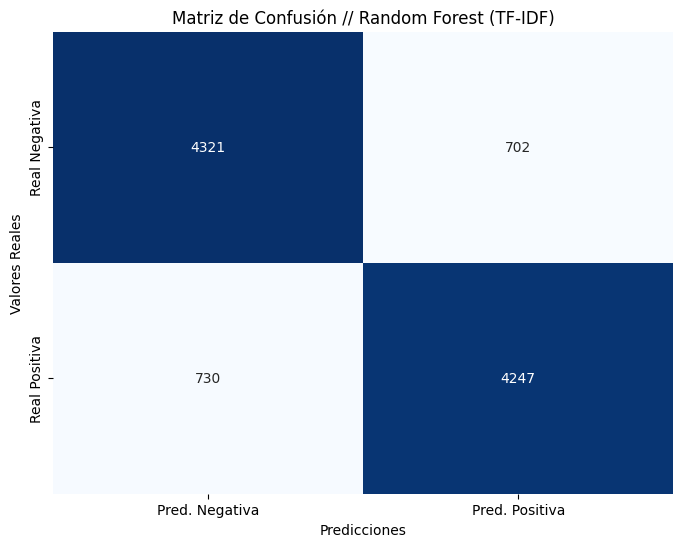



Modelo:KNN
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.82      0.70      0.76      5023
Clase 1 (Positiva)       0.74      0.84      0.79      4977

          accuracy                           0.77     10000
         macro avg       0.78      0.77      0.77     10000
      weighted avg       0.78      0.77      0.77     10000

AUC: 0.8471



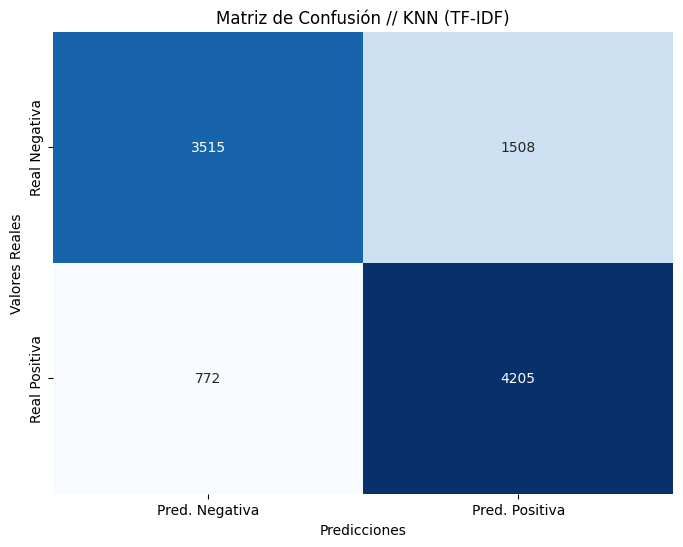



Modelo:Logistic Regression
                    precision    recall  f1-score   support

Clase 0 (Negativa)       0.90      0.88      0.89      5023
Clase 1 (Positiva)       0.88      0.91      0.89      4977

          accuracy                           0.89     10000
         macro avg       0.89      0.89      0.89     10000
      weighted avg       0.89      0.89      0.89     10000

AUC: 0.9595



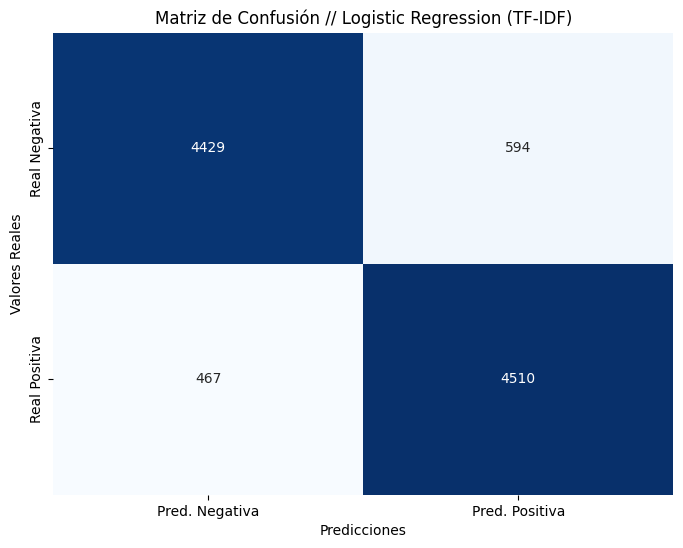

In [ ]:
#función para que cada modelo imprima su reporte
def reporte_matriz(X_train, y_train, X_test, y_test, nombre_estrategia):
  print(f'Reporte con {nombre_estrategia}:\n');separador()
  #no se pide, pero para encontrar realmente cual modelo se desempeña mejor, utilizo randomizedsearchcv con 5 folds
  grids = {
      'RandomForestClassifier': {
          'n_estimators': [100, 200, 500],
          'max_depth': [None, 10, 20, 30],
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 2, 4],
          'max_features': ['sqrt', 'log2']},
      'LogisticRegression': {
          'C': [0.01, 0.1, 1, 10, 100],
          'penalty': ['l1', 'l2'],
          'solver': ['liblinear', 'saga']},
      'KNeighborsClassifier': {
          'n_neighbors': [3, 5, 7, 11],
          'weights': ['uniform', 'distance'],
          'metric': ['euclidean', 'manhattan', 'minkowski']},
      'SVC': {
          'C': [0.1, 1, 10, 100],
          'kernel': ['linear', 'rbf', 'poly'],
          'gamma': ['scale', 'auto']},
      'MultinomialNB': {
          'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]}}

  for nombre, modelo in modelos.items():
    #aqui se busca la mejor combinación al azar
    if nombre in grids:
      search=RandomizedSearchCV(
          modelo,
          param_distributions=grids[nombre],
          n_iter=20,
          cv=5,
          scoring='f1',
          random_state=9,
          n_jobs=-1)
    modelo.fit(X_train, y_train)
    predicciones=modelo.predict(X_test)
    #Se calcula el area bajo la curva
    if hasattr(modelo, 'decision_function'):
      scores=modelo.decision_function(X_test)
    else:
      scores=modelo.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test, scores)
    print(f'Modelo:{nombre}')
    reporte=classification_report(y_test, predicciones, target_names=['Clase 0 (Negativa)', 'Clase 1 (Positiva)'])
    print(reporte)
    print(f'AUC: {auc:.4f}\n')

    #matriz
    matriz=confusion_matrix(y_test, predicciones)
    plt.figure(figsize=(8,6))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred. Negativa', 'Pred. Positiva'],
                yticklabels=['Real Negativa', 'Real Positiva'])
    plt.title(f'Matriz de Confusión // {nombre} ({nombre_estrategia})')
    plt.xlabel('Predicciones')
    plt.ylabel('Valores Reales')
    plt.show()
    separador()
reporte_matriz(X_entrenamiento_bow, y_entrenamiento, X_prueba_bow, y_prueba, 'BOW')
reporte_matriz(X_entrenamiento_tfidf, y_entrenamiento, X_prueba_tfidf, y_prueba, 'TF-IDF')

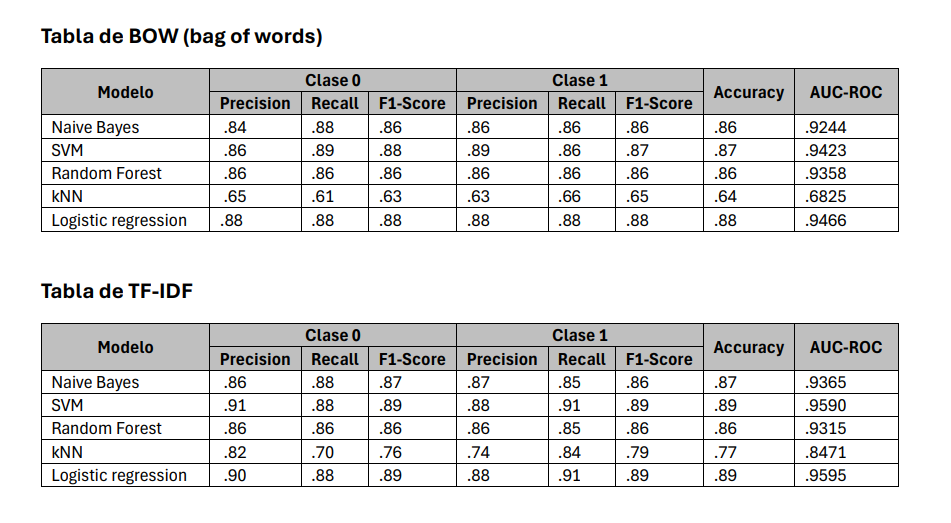

# Analiza y compara los resultados para responder lo siguiente:

**•	¿Cuál fue el mejor modelo en cada una de las tablas? Justifica tus respuestas en base a las métricas obtenidas.**

El mejor modelo en la tabla de bag of words fue regresión logistica. Su Accuracy es de .88 (mayor que los demás), su AUC de .9466 (que es el más alto entre los modelos), y su f1 de .88.

En la tabla de TF-IDF también arrojó mejor resultado la regresión logística. Su Accuracy es de .89 (empatado con SVM), AUC de .9595 (casi igual a SVM, pero le gana por muy poco), su f1 de .89, excelente balance.

**•	¿En qué estrategia funcionaron mejor los algoritmos de clasificación, en Bag of Words o en TF-IDF?**

La mejor estrategia fue TF-IDF, ya que las métricas mencionadas en la pregunta anterior fueron mejores. Esto porque repondera los tokens (rebaja palabras muy frecuentes, sube las raras y discriminativas) y ayuda especialmente a modelos lineales como la regresión y soporte vectorial.
